# GNN Model Implementation
> **Data Requirement:** This model requires `Data Files/negative_ProjectFinal_filtered_score0.1.csv`. 
> If you haven't generated it using the `SequenceIntegration` notebook, please download it [HERE](https://drive.google.com/file/d/1Aaw5wcOaLjBBvab3sXhod25xtk9jmJUp/view?usp=drive_link).

In [ ]:
%pip install Bio

  Using cached bio-1.8.1-py3-none-any.whl.metadata (5.7 kB)
  Using cached gprofiler_official-1.0.0-py3-none-any.whl.metadata (11 kB)
  Using cached mygene-3.2.2-py2.py3-none-any.whl.metadata (10 kB)
Using cached bio-1.8.1-py3-none-any.whl (321 kB)
Using cached gprofiler_official-1.0.0-py3-none-any.whl (9.3 kB)
Using cached mygene-3.2.2-py2.py3-none-any.whl (5.4 kB)

   -------------------------------- ------- 4/5 [Bio]
   ---------------------------------------- 5/5 [Bio]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


**Histograms**
To visualize the positive and negative datasets.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# File paths
positive_path = r"Data Files\positive_ProjectFinal.csv"
negative_path = r"Data Files\negative_ProjectFinal_filtered_score0.1.csv"

# Loading CSVs
pos_df = pd.read_csv(positive_path)
neg_df = pd.read_csv(negative_path)

# Converting Score to numeric values
pos_df["Score"] = pd.to_numeric(pos_df["Score"], errors="coerce")
neg_df["Score"] = pd.to_numeric(neg_df["Score"], errors="coerce")

# Dropping missing or invalid scores
pos_scores = pos_df["Score"].dropna()
neg_scores = neg_df["Score"].dropna()

# Histogram 1: Positive Dataset

plt.figure(figsize=(8, 5))
plt.hist(pos_scores, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.title("Histogram of Score Values (Positive Dataset)", fontsize=14)
plt.xlabel("Score", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Histogram 2: Negative Dataset

plt.figure(figsize=(8, 5))
plt.hist(neg_scores, bins=50, color='red', alpha=0.7, edgecolor='black')
plt.title("Histogram of Score Values (Negative Dataset)", fontsize=14)
plt.xlabel("Score", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


The **GNN** model

Device: cuda

Embedding all proteins...

===== FOLD 1 =====
Epoch 00 | Avg Iteration Loss: 0.1270
Epoch 05 | Avg Iteration Loss: 0.0481
Epoch 10 | Avg Iteration Loss: 0.0453
Epoch 15 | Avg Iteration Loss: 0.0439
Epoch 20 | Avg Iteration Loss: 0.0434
Epoch 25 | Avg Iteration Loss: 0.0403
Epoch 30 | Avg Iteration Loss: 0.0400
Epoch 35 | Avg Iteration Loss: 0.0418
Epoch 40 | Avg Iteration Loss: 0.0401
Epoch 45 | Avg Iteration Loss: 0.0490
Epoch 50 | Avg Iteration Loss: 0.0445
Epoch 54 | Avg Iteration Loss: 0.0429

===== FOLD 2 =====
Epoch 00 | Avg Iteration Loss: 0.1300
Epoch 05 | Avg Iteration Loss: 0.0492
Epoch 10 | Avg Iteration Loss: 0.0482
Epoch 15 | Avg Iteration Loss: 0.0450
Epoch 20 | Avg Iteration Loss: 0.0466
Epoch 25 | Avg Iteration Loss: 0.0469
Epoch 30 | Avg Iteration Loss: 0.0413
Epoch 35 | Avg Iteration Loss: 0.0461
Epoch 40 | Avg Iteration Loss: 0.0427
Epoch 45 | Avg Iteration Loss: 0.0390
Epoch 50 | Avg Iteration Loss: 0.0439
Epoch 54 | Avg Iteration Loss: 0.0409

===== F

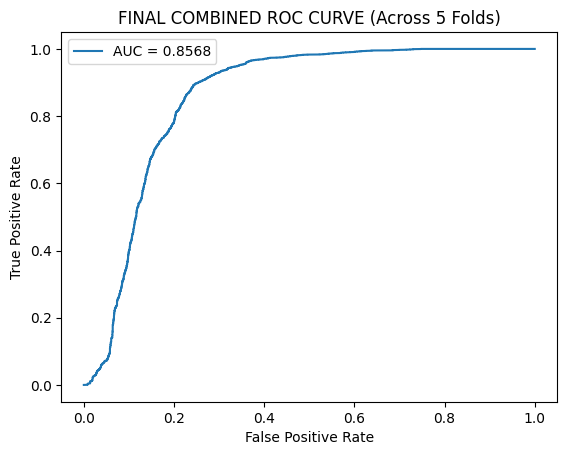

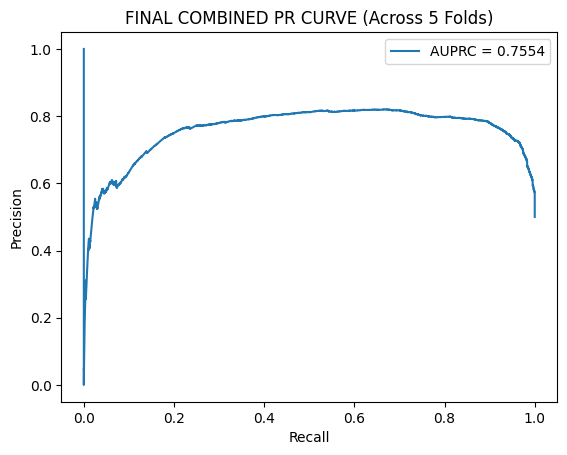


===== FINAL RESULTS (RESTORED OPTIMAL CONSTRUCTED RUN) =====
Accuracy:            0.8234
Precision:           0.8200
Recall:              0.8916
F1 Score:            0.8329
AUC-ROC:             0.8753
AUPRC:               0.8391
Balanced Accuracy:   0.8253
Matthews Coef (MCC): 0.6875


In [ ]:
# 1. Importing necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch_geometric.nn import GCNConv
from torch_geometric.loader import DataLoader  
from torch.utils.data import TensorDataset     
import pandas as pd
import numpy as np
from transformers import BertTokenizer, BertModel
from sklearn.model_selection import KFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, auc,
    balanced_accuracy_score, matthews_corrcoef  
)
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# 2. Loading ProtBERT model
tokenizer = BertTokenizer.from_pretrained("Rostlab/prot_bert", do_lower_case=False)
protbert = BertModel.from_pretrained("Rostlab/prot_bert").to(device)
protbert.eval()

MAX_LEN = 512

def embed_protein(seq):
    """Chunk-safe ProtBERT embedding"""
    seq = seq.replace(" ", "").upper()
    chunks = [seq[i:i+MAX_LEN] for i in range(0, len(seq), MAX_LEN)]

    reps = []
    for ch in chunks:
        spaced = " ".join(list(ch))
        inputs = tokenizer(spaced, return_tensors="pt").to(device)
        with torch.no_grad():
            out = protbert(**inputs)
        reps.append(out.last_hidden_state[:,0,:])   # CLS token

    rep = torch.mean(torch.stack(reps), dim=0)      # Mean pool chunks
    return rep.squeeze(0)

# 3. Loading data files
pos_df = pd.read_csv(r"Data Files\positive_ProjectFinal.csv")
neg_df = pd.read_csv(r"Data Files\negative_ProjectFinal_filtered_score0.1.csv")

neg_df = neg_df.sample(n=len(pos_df), random_state=42).reset_index(drop=True)

df = pd.concat([pos_df, neg_df], ignore_index=True)
df["Label"] = [1]*len(pos_df) + [0]*len(neg_df)

# 4. Building node dictionary
all_humans = df["Human"].unique().tolist()
all_viruses = df["SARS-CoV2"].unique().tolist()

human_to_id = {h: i for i, h in enumerate(all_humans)}
virus_to_id = {v: i+len(all_humans) for i, v in enumerate(all_viruses)}

num_nodes = len(all_humans) + len(all_viruses)

# 5. Embedding all proteins
print("\nEmbedding all proteins...")
node_features = torch.zeros((num_nodes, 1024), device=device)

for h in all_humans:
    node_features[human_to_id[h]] = embed_protein(
        df[df["Human"] == h]["Human_Sequence"].iloc[0]
    )

for v in all_viruses:
    node_features[virus_to_id[v]] = embed_protein(
        df[df["SARS-CoV2"] == v]["SARS-CoV2_Sequence"].iloc[0]
    )

# 6. Structuring pairs
pairs_list = []
for i, row in df.iterrows():
    u = human_to_id[row["Human"]]
    v = virus_to_id[row["SARS-CoV2"]]
    pairs_list.append([u, v])

edge_pairs = torch.tensor(pairs_list, dtype=torch.long)
labels = torch.tensor(df["Label"].values).long()

# 7. The GCN model 
class GCN(nn.Module):
    def __init__(self, in_dim=1024, hid=512, out_dim=256):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hid)
        self.conv2 = GCNConv(hid, out_dim)
        self.relu = nn.ReLU()

        self.edge_mlp = nn.Sequential(
            nn.Linear(out_dim * 2, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x, edge_index, edge_pairs):
        x = self.relu(self.conv1(x, edge_index))
        x = self.conv2(x, edge_index)

        u = x[edge_pairs[:, 0]]
        v = x[edge_pairs[:, 1]]
        uv = torch.cat([u, v], dim=1)

        return self.edge_mlp(uv).squeeze()

# 8. The K-fold training 
kf = KFold(n_splits=5, shuffle=True, random_state=42)

final_metrics = []
all_probs = []
all_true = []

BATCH_SIZE = 256

for fold, (train_i, test_i) in enumerate(kf.split(edge_pairs)):
    print(f"\n===== FOLD {fold+1} =====")
    fold_train_edges = edge_pairs[train_i]
    
    edge_list = []
    for pair in fold_train_edges:
        u = pair[0].item()
        v = pair[1].item()
        edge_list.append([u, v])
        edge_list.append([v, u]) 
        
    fold_edge_index = torch.tensor(edge_list, dtype=torch.long).t().to(device)

    model = GCN().to(device)
    opt = optim.Adam(model.parameters(), lr=5e-4) 
    loss_fn = nn.BCELoss()

    train_dataset = TensorDataset(edge_pairs[train_i], labels[train_i])
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

    test_dataset = TensorDataset(edge_pairs[test_i], labels[test_i])
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # - Train for 55 Epochs -
    for epoch in range(55):
        model.train()
        epoch_loss = 0.0
        iterations = 0
        
        for batch_pairs, batch_labels in train_loader:
            batch_pairs = batch_pairs.to(device)
            batch_labels = batch_labels.to(device).float()
            
            opt.zero_grad()
            out = model(node_features, fold_edge_index, batch_pairs)
            loss = loss_fn(out, batch_labels)
            loss.backward()
            opt.step()
            
            epoch_loss += loss.item()
            iterations += 1

        if epoch % 5 == 0 or epoch == 54:
            avg_loss = epoch_loss / iterations
            print(f"Epoch {epoch:02d} | Avg Iteration Loss: {avg_loss:.4f}")

    # - Test -
    model.eval()
    fold_probs = []
    fold_true = []
    
    with torch.no_grad():
        for batch_pairs, batch_labels in test_loader:
            batch_pairs = batch_pairs.to(device)
            probs = model(node_features, fold_edge_index, batch_pairs).cpu().numpy()
            
            if probs.ndim == 0: 
                probs = np.array([probs])
                
            fold_probs.extend(probs)
            fold_true.extend(batch_labels.numpy())

    fold_probs = np.array(fold_probs)
    fold_true = np.array(fold_true)
    fold_preds = (fold_probs >= 0.5).astype(int)

    all_probs.extend(fold_probs)
    all_true.extend(fold_true)

    # Metrics calculation
    acc = accuracy_score(fold_true, fold_preds)
    prec = precision_score(fold_true, fold_preds, zero_division=0)
    rec = recall_score(fold_true, fold_preds, zero_division=0)
    f1 = f1_score(fold_true, fold_preds, zero_division=0)
    auc_val = roc_auc_score(fold_true, fold_probs)

    p_vals, r_vals, _ = precision_recall_curve(fold_true, fold_probs)
    pr_auc = auc(r_vals, p_vals)
    
    bal_acc = balanced_accuracy_score(fold_true, fold_preds)
    mcc = matthews_corrcoef(fold_true, fold_preds)

    final_metrics.append([acc, prec, rec, f1, auc_val, pr_auc, bal_acc, mcc])

# 9. Combined ROC & PR curves for all 5 folds
all_probs = np.array(all_probs)
all_true = np.array(all_true)

fpr, tpr, _ = roc_curve(all_true, all_probs)
roc_auc_val = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc_val:.4f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("FINAL COMBINED ROC CURVE (Across 5 Folds)")
plt.legend()
plt.show()

precision_vals, recall_vals, _ = precision_recall_curve(all_true, all_probs)
pr_auc_val = auc(recall_vals, precision_vals)

plt.plot(recall_vals, precision_vals, label=f"AUPRC = {pr_auc_val:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("FINAL COMBINED PR CURVE (Across 5 Folds)")
plt.legend()
plt.show()

# 10. Final metrics averaged across all 5 folds
m = np.array(final_metrics)

print("\n===== FINAL RESULTS (RESTORED OPTIMAL CONSTRUCTED RUN) =====")
print(f"Accuracy:            {m[:,0].mean():.4f}")
print(f"Precision:           {m[:,1].mean():.4f}")
print(f"Recall:              {m[:,2].mean():.4f}")
print(f"F1 Score:            {m[:,3].mean():.4f}")
print(f"AUC-ROC:             {m[:,4].mean():.4f}")
print(f"AUPRC:               {m[:,5].mean():.4f}")
print(f"Balanced Accuracy:   {m[:,6].mean():.4f}")
print(f"Matthews Coef (MCC): {m[:,7].mean():.4f}")